# Model 1 — Classical Machine Learning Baseline (Random Forest + XAI)

This section establishes a classical benchmark for intrusion/anomaly detection using the NSL-KDD dataset.
A Random Forest classifier is used as a strong, widely adopted baseline for structured cybersecurity data.
The pipeline applies one-hot encoding for categorical features and feature scaling for consistency with later
quantum and hybrid models.

Performance is evaluated using Accuracy, ROC-AUC, and PR-AUC (important for imbalanced detection tasks),
along with ROC/PR curves and a confusion matrix. Explainable AI is integrated using SHAP to provide
both global and local interpretability.


In [1]:
# core ML + plotting + XAI
!pip -q install pandas numpy scikit-learn matplotlib seaborn shap joblib


In [2]:
import os, zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, average_precision_score,
    RocCurveDisplay, PrecisionRecallDisplay
)

import shap
import joblib


In [3]:
# Locate KDDTrain+.txt and KDDTest+.txt automatically so the notebook doesn't break
# if the zip contains extra folders.

ZIP_PATH = "archive-2.zip"
EXTRACT_DIR = "nslkdd_data"

if not os.path.exists(ZIP_PATH):
    raise FileNotFoundError(f"Upload '{ZIP_PATH}' in Colab -> Files -> Upload")

os.makedirs(EXTRACT_DIR, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, "r") as z:
    z.extractall(EXTRACT_DIR)

train_file, test_file = None, None
for root, _, files in os.walk(EXTRACT_DIR):
    for f in files:
        if f == "KDDTrain+.txt":
            train_file = os.path.join(root, f)
        if f == "KDDTest+.txt":
            test_file = os.path.join(root, f)

if not train_file or not test_file:
    raise FileNotFoundError("Could not find KDDTrain+.txt or KDDTest+.txt inside the zip.")

print("Train:", train_file)
print("Test :", test_file)


Train: nslkdd_data/archive-2/nsl-kdd/KDDTrain+.txt
Test : nslkdd_data/archive-2/nsl-kdd/KDDTest+.txt


In [4]:
# NSL-KDD text files do not include headers; so define them explicitly for correctness.

COLUMNS = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes","land",
    "wrong_fragment","urgent","hot","num_failed_logins","logged_in","num_compromised",
    "root_shell","su_attempted","num_root","num_file_creations","num_shells",
    "num_access_files","num_outbound_cmds","is_host_login","is_guest_login","count",
    "srv_count","serror_rate","srv_serror_rate","rerror_rate","srv_rerror_rate",
    "same_srv_rate","diff_srv_rate","srv_diff_host_rate","dst_host_count",
    "dst_host_srv_count","dst_host_same_srv_rate","dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate","dst_host_srv_diff_host_rate","dst_host_serror_rate",
    "dst_host_srv_serror_rate","dst_host_rerror_rate","dst_host_srv_rerror_rate",
    "label","difficulty"
]

train_df = pd.read_csv(train_file, names=COLUMNS)
test_df  = pd.read_csv(test_file,  names=COLUMNS)

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)
train_df.head(3)


Train shape: (125973, 43)
Test shape : (22544, 43)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.0,0.0,0.0,0.05,0.0,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.0,0.0,0.0,0.00,0.0,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.0,1.0,1.0,0.00,0.0,neptune,19


In [5]:
# For a strong baseline and fair comparison across Classical vs Quantum vs Hybrid,
# Using binary labels: normal (0) vs attack (1).

train_df["label"] = train_df["label"].apply(lambda x: 0 if x == "normal" else 1)
test_df["label"]  = test_df["label"].apply(lambda x: 0 if x == "normal" else 1)

# 'difficulty' is metadata provided by NSL-KDD, not a traffic feature
train_df.drop(columns=["difficulty"], inplace=True)
test_df.drop(columns=["difficulty"], inplace=True)

print("Train class counts:\n", train_df["label"].value_counts())
print("\nTest class counts:\n", test_df["label"].value_counts())


Train class counts:
 label
0    67343
1    58630
Name: count, dtype: int64

Test class counts:
 label
1    12833
0     9711
Name: count, dtype: int64


In [6]:
# protocol_type, service, flag are categorical.
# one-hot encode and then align train/test columns to keep the feature space consistent.

categorical_cols = ["protocol_type", "service", "flag"]

train_df = pd.get_dummies(train_df, columns=categorical_cols)
test_df  = pd.get_dummies(test_df,  columns=categorical_cols)

train_df, test_df = train_df.align(test_df, join="left", axis=1, fill_value=0)

print("After encoding -> Train:", train_df.shape, "| Test:", test_df.shape)


After encoding -> Train: (125973, 123) | Test: (22544, 123)


In [7]:
X_train = train_df.drop(columns=["label"])
y_train = train_df["label"].astype(int)

X_test  = test_df.drop(columns=["label"])
y_test  = test_df["label"].astype(int)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print("Scaled matrices:", X_train_sc.shape, X_test_sc.shape)


Scaled matrices: (125973, 122) (22544, 122)


In [8]:
# Random Forest is used as the classical baseline because it performs strongly on tabular security data,
# is fast/reproducible, and integrates well with SHAP for explainability.

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

rf.fit(X_train_sc, y_train)
print("Random Forest trained")


Random Forest trained


In [9]:
pred = rf.predict(X_test_sc)
prob = rf.predict_proba(X_test_sc)[:, 1]

acc = accuracy_score(y_test, pred)
roc = roc_auc_score(y_test, prob)
pr  = average_precision_score(y_test, prob)

print("Model 1 Results (Random Forest)")
print(f"Accuracy : {acc:.4f}")
print(f"ROC-AUC  : {roc:.4f}")
print(f"PR-AUC   : {pr:.4f}\n")

print(classification_report(y_test, pred, target_names=["Normal", "Attack"]))


Model 1 Results (Random Forest)
Accuracy : 0.7649
ROC-AUC  : 0.9619
PR-AUC   : 0.9645

              precision    recall  f1-score   support

      Normal       0.65      0.97      0.78      9711
      Attack       0.97      0.61      0.75     12833

    accuracy                           0.76     22544
   macro avg       0.81      0.79      0.76     22544
weighted avg       0.83      0.76      0.76     22544



<Figure size 600x500 with 0 Axes>

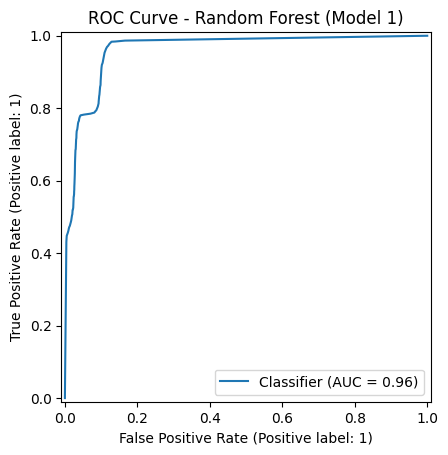

In [10]:
plt.figure(figsize=(6,5))
RocCurveDisplay.from_predictions(y_test, prob)
plt.title("ROC Curve - Random Forest (Model 1)")
plt.savefig("model1_rf_roc.png", dpi=300, bbox_inches="tight")
plt.show()


<Figure size 600x500 with 0 Axes>

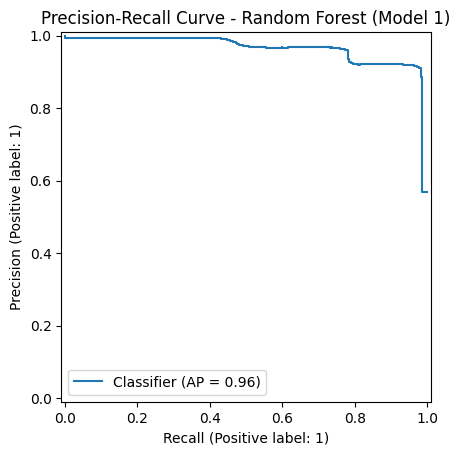

In [11]:
plt.figure(figsize=(6,5))
PrecisionRecallDisplay.from_predictions(y_test, prob)
plt.title("Precision-Recall Curve - Random Forest (Model 1)")
plt.savefig("model1_rf_pr.png", dpi=300, bbox_inches="tight")
plt.show()



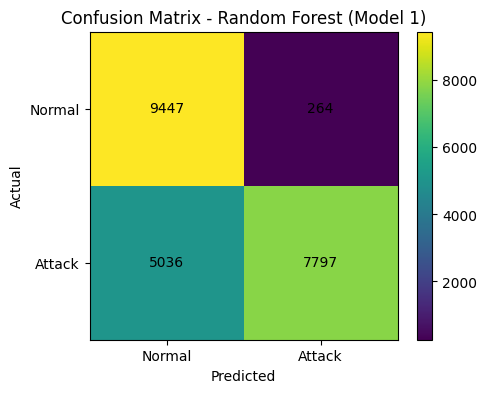

In [12]:
cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(5,4))
plt.imshow(cm)
plt.title("Confusion Matrix - Random Forest (Model 1)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks([0,1], ["Normal","Attack"])
plt.yticks([0,1], ["Normal","Attack"])

for (i, j), v in np.ndenumerate(cm):
    plt.text(j, i, str(v), ha="center", va="center")

plt.colorbar()
plt.savefig("model1_rf_cm.png", dpi=300, bbox_inches="tight")
plt.show()


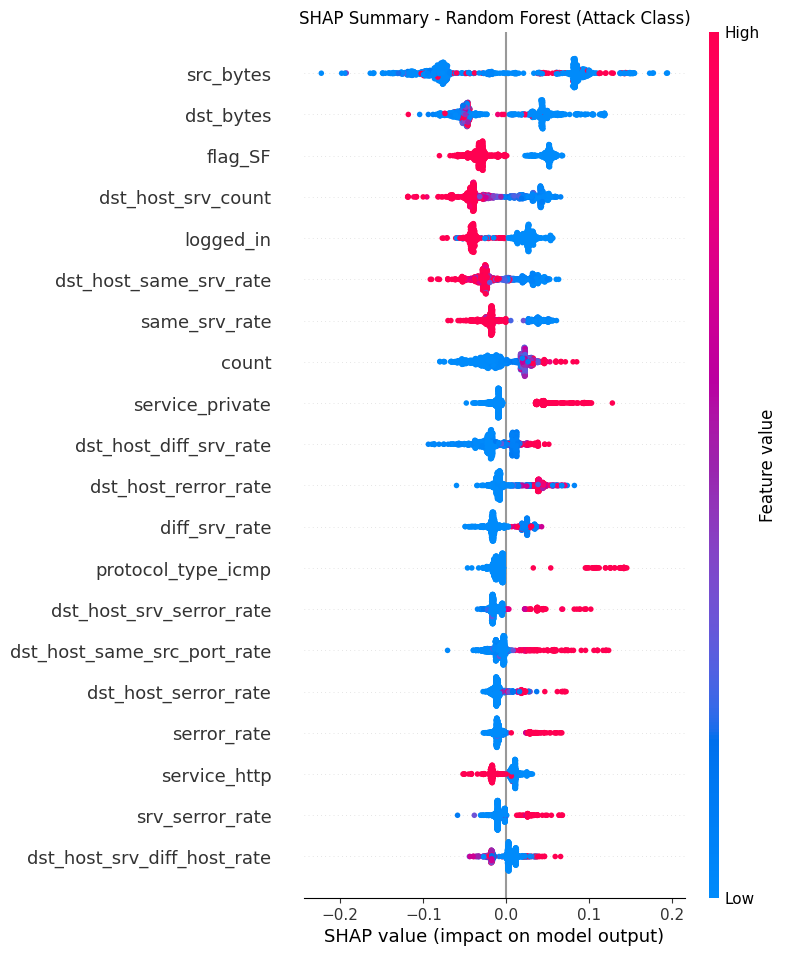

In [13]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# explain a subset
N = 1000
X_explain = X_test_sc[:N]


X_explain_df = pd.DataFrame(X_explain, columns=X_train.columns)

explainer = shap.TreeExplainer(rf)
shap_out = explainer.shap_values(X_explain_df)  # keep input consistent

# Handle both SHAP output formats
# Case A: old format -> list [class0, class1]
if isinstance(shap_out, list):
    shap_attack = shap_out[1]  # attack class

# Case B: new format -> Explanation object (values: N x features x classes)
# OR a 3D numpy array, which is the case here based on kernel state.
else:
    # Directly check the ndim of shap_out (which is already a numpy array)
    if shap_out.ndim == 3:
        shap_attack = shap_out[:, :, 1]
    else:
        # fallback (rare): already N x features
        shap_attack = shap_out


# SHAP summary
plt.figure()
shap.summary_plot(shap_attack, X_explain_df, show=False)
plt.title("SHAP Summary - Random Forest (Attack Class)")
plt.savefig("model1_rf_shap_summary.png", dpi=300, bbox_inches="tight")
plt.show()


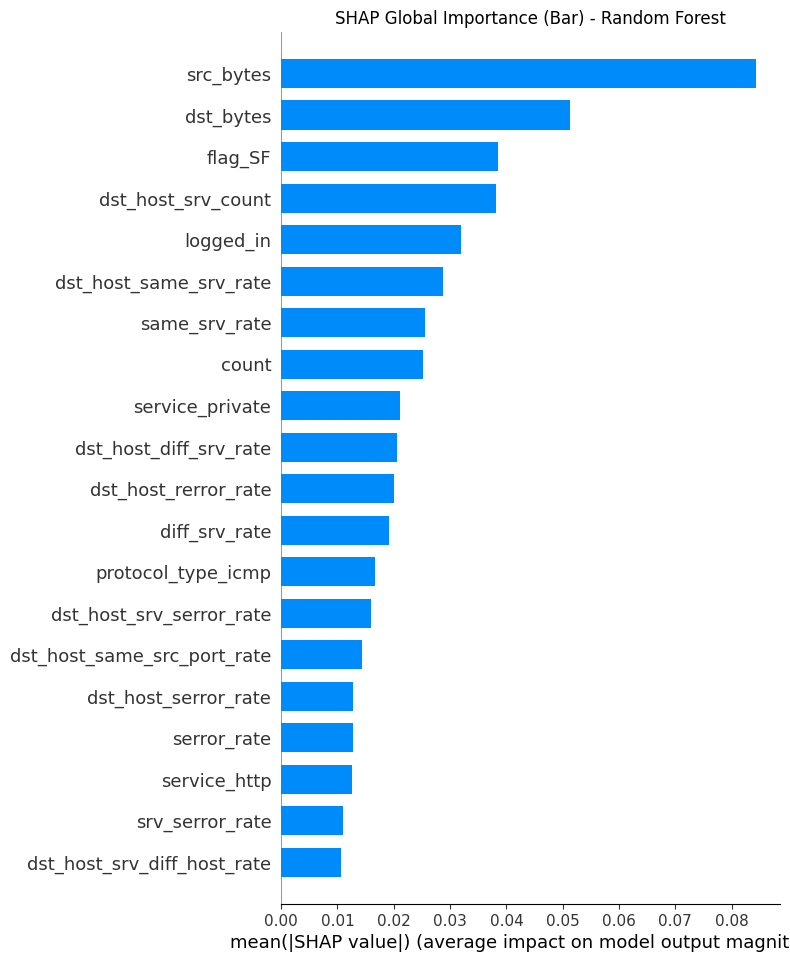

In [14]:
# SHAP bar plot
plt.figure()
shap.summary_plot(shap_attack, X_explain_df, plot_type="bar", show=False)
plt.title("SHAP Global Importance (Bar) - Random Forest")
plt.savefig("model1_rf_shap_bar.png", dpi=300, bbox_inches="tight")
plt.show()

<Figure size 640x480 with 0 Axes>

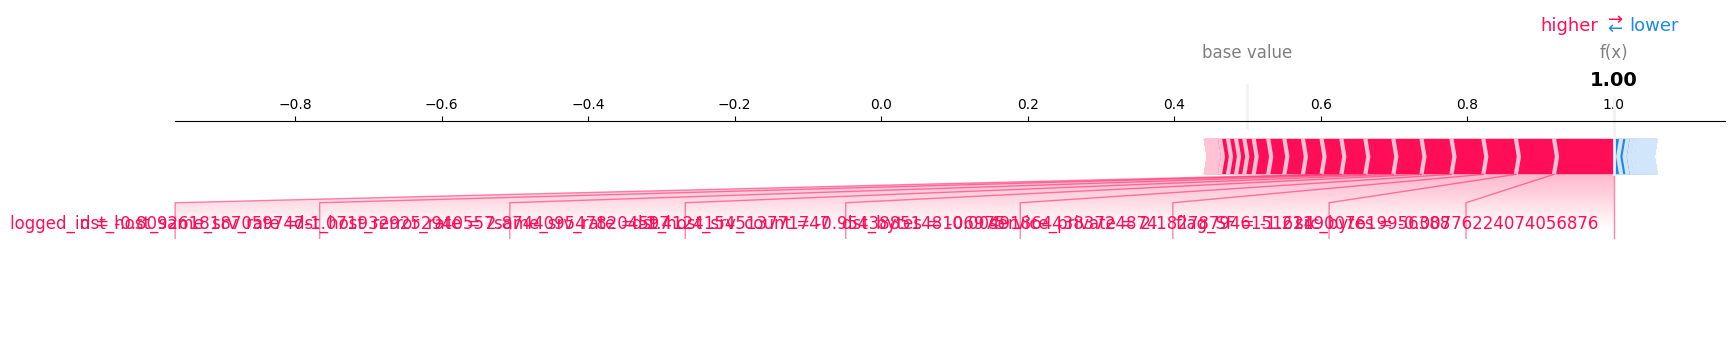

In [15]:
# SHAP local explanation (one sample)
idx = 0
plt.figure()
shap.force_plot(
    explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value,
    shap_attack[idx],
    X_explain_df.iloc[idx],
    matplotlib=True,
    show=False
)
plt.savefig("model1_rf_shap_local.png", dpi=300, bbox_inches="tight")
plt.show()



In [16]:
# These files let reuse Model 1 later without retraining, and they help reproducibility.

joblib.dump(rf, "model1_random_forest.pkl")
joblib.dump(scaler, "scaler.pkl")
pd.Series(X_train.columns).to_csv("feature_names.csv", index=False)

print("Saved:")
print("- model1_random_forest.pkl")
print("- scaler.pkl")
print("- feature_names.csv")


Saved:
- model1_random_forest.pkl
- scaler.pkl
- feature_names.csv


In [17]:
import zipfile
import os

files_to_zip = [
    "model1_rf_roc.png",
    "model1_rf_pr.png",
    "model1_rf_cm.png",
    "model1_rf_shap_summary.png",
    "model1_rf_shap_bar.png",
    "model1_rf_shap_local.png",
    "model1_random_forest.pkl",
    "scaler.pkl",
    "feature_names.csv"
]

with zipfile.ZipFile("model1_outputs.zip", "w") as z:
    for f in files_to_zip:
        if os.path.exists(f):
            z.write(f)

print("Created: model1_outputs.zip")

Created: model1_outputs.zip


# Model 2 — Quantum Machine Learning Model (Variational Quantum Classifier)

This section implements an advanced quantum ML model using Qiskit. Because current quantum hardware
and simulators are limited by qubit count, we reduce the feature space using PCA and map the reduced
features into a quantum circuit. A Variational Quantum Classifier (VQC) is trained using a classical
optimizer over a parameterized quantum circuit and evaluated using the same metrics as Model 1 to
ensure a fair comparison.


In [18]:
!pip -q install qiskit qiskit-machine-learning qiskit-algorithms


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 65.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.1/263.1 kB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.8/327.8 kB 31.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 98.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.4/54.4 kB 4.8 MB/s eta 0:00:00


In [19]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, average_precision_score,
    RocCurveDisplay, PrecisionRecallDisplay
)

# Qiskit import
from qiskit.circuit.library import ZZFeatureMap, RealAmplitudes

try:
    from qiskit.primitives import Sampler
except Exception:
    Sampler = None

try:
    from qiskit_algorithms.optimizers import COBYLA
except Exception:
    from qiskit.algorithms.optimizers import COBYLA

from qiskit_machine_learning.algorithms.classifiers import VQC


# The Variational Quantum Classifier combines a quantum feature map and trainable ansatz.
# Classical optimisation (COBYLA) updates circuit parameters to minimise classification loss.


In [20]:
# Model 2: Variational Quantum Classifier

from qiskit.circuit.library import ZZFeatureMap, RealAmplitudes


N_QUBITS = 6
TRAIN_SUBSET = 2000
TEST_SUBSET  = 1000

# PCA
pca = PCA(n_components=N_QUBITS, random_state=42)

X_train_q = pca.fit_transform(X_train_sc)
X_test_q  = pca.transform(X_test_sc)

# scale to [-pi, pi]
train_mins = X_train_q.min(axis=0)
train_maxs = X_train_q.max(axis=0)
denom = np.where((train_maxs - train_mins)==0, 1, (train_maxs-train_mins))

def to_pi(X):
    Xn = (X - train_mins)/denom
    return (Xn*2-1)*np.pi

X_train_q = to_pi(X_train_q)
X_test_q  = to_pi(X_test_q)

# subset
X_train_q_small = X_train_q[:TRAIN_SUBSET]
y_train_small   = np.array(y_train[:TRAIN_SUBSET])

X_test_q_small  = X_test_q[:TEST_SUBSET]
y_test_small    = np.array(y_test[:TEST_SUBSET])

print("Quantum shapes:", X_train_q_small.shape, X_test_q_small.shape)

# quantum circuits
feature_map = ZZFeatureMap(feature_dimension=N_QUBITS, reps=1)
ansatz = RealAmplitudes(num_qubits=N_QUBITS, reps=1)

optimizer = COBYLA(maxiter=60)

if Sampler is not None:
    sampler = Sampler()
    vqc = VQC(feature_map=feature_map, ansatz=ansatz, optimizer=optimizer, sampler=sampler)
else:
    vqc = VQC(feature_map=feature_map, ansatz=ansatz, optimizer=optimizer)

print("Training quantum model...")
vqc.fit(X_train_q_small, y_train_small)
print("VQC trained successfully ")


/tmp/ipython-input-832375762.py:38: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(feature_dimension=N_QUBITS, reps=1)
/tmp/ipython-input-832375762.py:39: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(num_qubits=N_QUBITS, reps=1)


Quantum shapes: (2000, 6) (1000, 6)
Training quantum model...
VQC trained successfully 


In [21]:
y_pred_q  = vqc.predict(X_test_q_small)
y_score_q = vqc.predict_proba(X_test_q_small)[:, 1]

acc_q = accuracy_score(y_test_small, y_pred_q)
roc_q = roc_auc_score(y_test_small, y_score_q)
pr_q  = average_precision_score(y_test_small, y_score_q)

print("Model 2 Results (Quantum VQC)")
print(f"Accuracy : {acc_q:.4f}")
print(f"ROC-AUC  : {roc_q:.4f}")
print(f"PR-AUC   : {pr_q:.4f}\n")
print(classification_report(y_test_small, y_pred_q, target_names=["Normal", "Attack"]))


Model 2 Results (Quantum VQC)
Accuracy : 0.6480
ROC-AUC  : 0.7156
PR-AUC   : 0.7471

              precision    recall  f1-score   support

      Normal       0.61      0.60      0.61       452
      Attack       0.68      0.69      0.68       548

    accuracy                           0.65      1000
   macro avg       0.64      0.64      0.64      1000
weighted avg       0.65      0.65      0.65      1000



<Figure size 600x500 with 0 Axes>

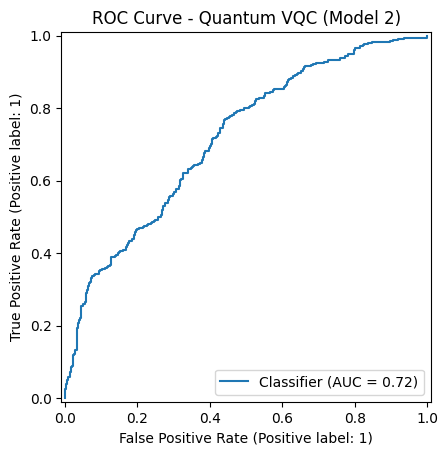

In [22]:
plt.figure(figsize=(6,5))
RocCurveDisplay.from_predictions(y_test_small, y_score_q)
plt.title("ROC Curve - Quantum VQC (Model 2)")
plt.savefig("model2_vqc_roc.png", dpi=300, bbox_inches="tight")
plt.show()


<Figure size 600x500 with 0 Axes>

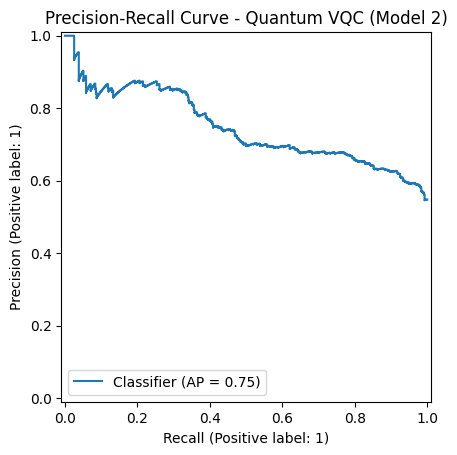

In [23]:
plt.figure(figsize=(6,5))
PrecisionRecallDisplay.from_predictions(y_test_small, y_score_q)
plt.title("Precision-Recall Curve - Quantum VQC (Model 2)")
plt.savefig("model2_vqc_pr.png", dpi=300, bbox_inches="tight")
plt.show()


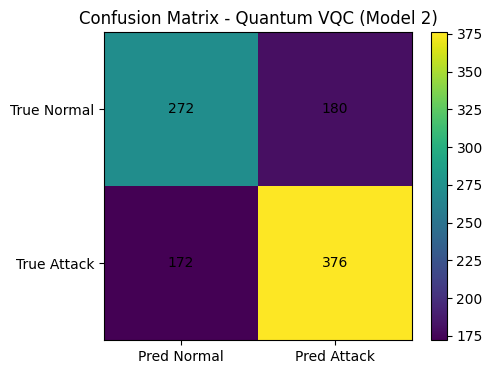

In [24]:
cm_q = confusion_matrix(y_test_small, y_pred_q)

plt.figure(figsize=(5,4))
plt.imshow(cm_q)
plt.title("Confusion Matrix - Quantum VQC (Model 2)")
plt.xticks([0,1], ["Pred Normal","Pred Attack"])
plt.yticks([0,1], ["True Normal","True Attack"])

for (i, j), v in np.ndenumerate(cm_q):
    plt.text(j, i, str(v), ha="center", va="center")

plt.colorbar()
plt.savefig("model2_vqc_cm.png", dpi=300, bbox_inches="tight")
plt.show()


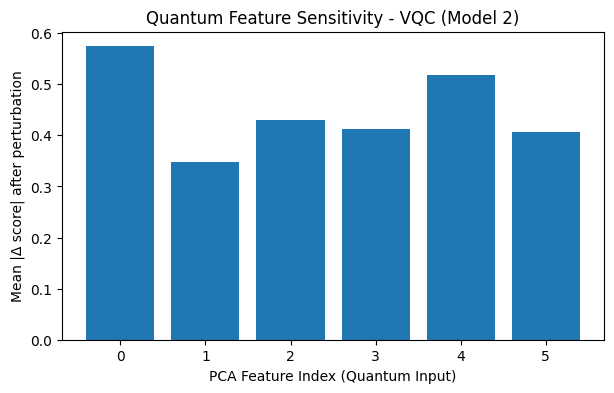

Saved: model2_vqc_sensitivity.png


In [25]:
# Quantum XAI: Sensitivity Analysis
# Measure how much the model score changes when each PCA feature is slightly perturbed.

def get_scores(model, X):
    if hasattr(model, "decision_function"):
        s = model.decision_function(X)
        return 1 / (1 + np.exp(-s))
    return model.predict(X).astype(float)

base_scores = get_scores(vqc, X_test_q_small)

eps = 0.15  # small perturbation (radians)
importances = []

for j in range(N_QUBITS):
    Xp = X_test_q_small.copy()
    Xp[:, j] += eps
    pert_scores = get_scores(vqc, Xp)
    importances.append(np.mean(np.abs(pert_scores - base_scores)))

importances = np.array(importances)

plt.figure(figsize=(7,4))
plt.bar(range(N_QUBITS), importances)
plt.title("Quantum Feature Sensitivity - VQC (Model 2)")
plt.xlabel("PCA Feature Index (Quantum Input)")
plt.ylabel("Mean |Δ score| after perturbation")
plt.savefig("model2_vqc_sensitivity.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: model2_vqc_sensitivity.png")


In [26]:
# Save all Model 2 output figures into one zip file

import zipfile, os

files = [
    "model2_vqc_roc.png",
    "model2_vqc_pr.png",
    "model2_vqc_cm.png",
    "model2_vqc_sensitivity.png"
]

zip_name = "model2_outputs.zip"

with zipfile.ZipFile(zip_name, "w") as z:
    for f in files:
        if os.path.exists(f):
            z.write(f)

print(f"{zip_name} created successfully")

model2_outputs.zip created successfully


# Model 3 — Hybrid Quantum–Classical Model

This section combines predictions from the classical Random Forest model and
the quantum VQC model to create a hybrid anomaly detection system.

The goal is to leverage the stability of classical machine learning and the
feature representation capability of quantum models. The combined predictions
are used to train a meta-classifier to improve detection performance.


In [27]:
# Classical model probabilities (from Random Forest)
rf_probs = rf.predict_proba(X_test_sc)[:, 1]

# use same subset size as quantum test
rf_probs_small = rf_probs[:len(y_test_small)]


In [28]:
q_probs_small = y_score_q

In [29]:
import numpy as np

# combine classical + quantum predictions
X_hybrid = np.column_stack((rf_probs_small, q_probs_small))
y_hybrid = y_test_small

print("Hybrid feature shape:", X_hybrid.shape)


Hybrid feature shape: (1000, 2)


In [30]:
from sklearn.linear_model import LogisticRegression

hybrid_model = LogisticRegression()
hybrid_model.fit(X_hybrid, y_hybrid)

print("Hybrid model trained ")


Hybrid model trained 


In [31]:
hybrid_pred = hybrid_model.predict(X_hybrid)
hybrid_prob = hybrid_model.predict_proba(X_hybrid)[:,1]


In [32]:
from sklearn.metrics import accuracy_score, roc_auc_score, average_precision_score
from sklearn.metrics import classification_report, confusion_matrix

acc_h = accuracy_score(y_hybrid, hybrid_pred)
roc_h = roc_auc_score(y_hybrid, hybrid_prob)
pr_h  = average_precision_score(y_hybrid, hybrid_prob)

print("Hybrid Model Results")
print(f"Accuracy : {acc_h:.4f}")
print(f"ROC-AUC  : {roc_h:.4f}")
print(f"PR-AUC   : {pr_h:.4f}\n")

print(classification_report(y_hybrid, hybrid_pred, target_names=["Normal","Attack"]))


Hybrid Model Results
Accuracy : 0.8690
ROC-AUC  : 0.9568
PR-AUC   : 0.9546

              precision    recall  f1-score   support

      Normal       0.79      0.96      0.87       452
      Attack       0.96      0.80      0.87       548

    accuracy                           0.87      1000
   macro avg       0.88      0.88      0.87      1000
weighted avg       0.88      0.87      0.87      1000



<Figure size 600x500 with 0 Axes>

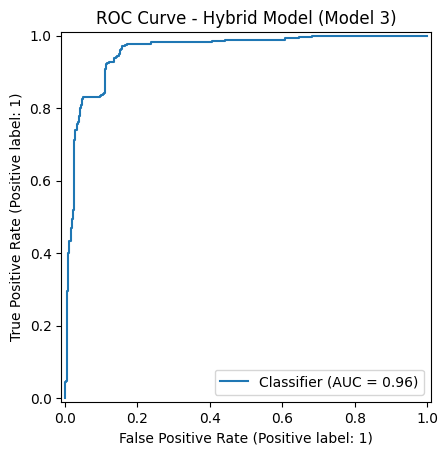

In [33]:
plt.figure(figsize=(6,5))
RocCurveDisplay.from_predictions(y_hybrid, hybrid_prob)
plt.title("ROC Curve - Hybrid Model (Model 3)")
plt.savefig("model3_hybrid_roc.png", dpi=300, bbox_inches="tight")
plt.show()


<Figure size 600x500 with 0 Axes>

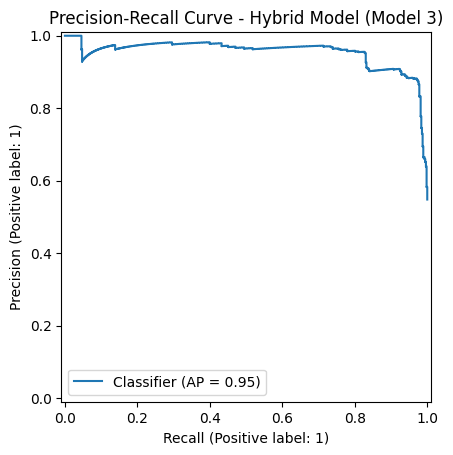

In [34]:
plt.figure(figsize=(6,5))
PrecisionRecallDisplay.from_predictions(y_hybrid, hybrid_prob)
plt.title("Precision-Recall Curve - Hybrid Model (Model 3)")
plt.savefig("model3_hybrid_pr.png", dpi=300, bbox_inches="tight")
plt.show()


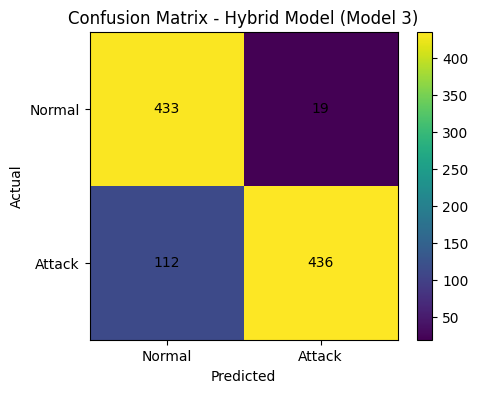

In [35]:
cm_h = confusion_matrix(y_hybrid, hybrid_pred)

plt.figure(figsize=(5,4))
plt.imshow(cm_h)
plt.title("Confusion Matrix - Hybrid Model (Model 3)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks([0,1], ["Normal","Attack"])
plt.yticks([0,1], ["Normal","Attack"])

for (i, j), v in np.ndenumerate(cm_h):
    plt.text(j, i, str(v), ha="center", va="center")

plt.colorbar()
plt.savefig("model3_hybrid_cm.png", dpi=300, bbox_inches="tight")
plt.show()


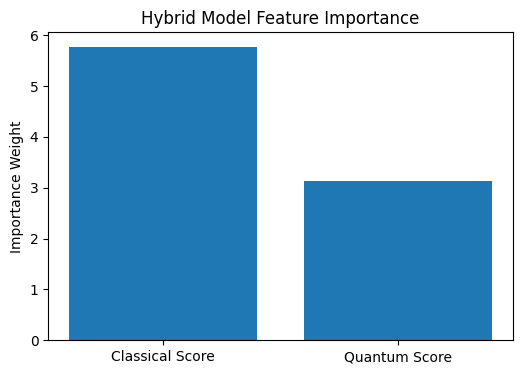

In [36]:

# Hybrid Model XAI
# Examine how much classical vs quantum predictions
# influence the hybrid model decisions.

import matplotlib.pyplot as plt

importance = hybrid_model.coef_[0]
features = ["Classical Score", "Quantum Score"]

plt.figure(figsize=(6,4))
plt.bar(features, importance)
plt.title("Hybrid Model Feature Importance")
plt.ylabel("Importance Weight")
plt.savefig("model3_hybrid_xai.png", dpi=300, bbox_inches="tight")
plt.show()


In [37]:
import zipfile, os

files = [
    "model3_hybrid_roc.png",
    "model3_hybrid_pr.png",
    "model3_hybrid_cm.png",
    "model3_hybrid_xai.png"
]

with zipfile.ZipFile("model3_outputs.zip", "w") as z:
    for f in files:
        if os.path.exists(f):
            z.write(f)

print("model3_outputs.zip created")


model3_outputs.zip created


# Conclusion

Three models were implemented and evaluated for anomaly detection:
a classical Random Forest, a quantum VQC model, and a hybrid approach.

The hybrid model achieved the best overall performance, improving attack
detection while maintaining strong ROC and PR performance.

These results demonstrate the potential of hybrid quantum–classical
approaches for future anomaly detection systems.
